# Tutorial: $k$-Means Clustering

In this tutorial we will explore the $k$-means clustering algorithm, an unsupervised machine learning method.  As usual, we will implement the algorithms using Python and NumPy, with only a little help from sklearn.  

In [354]:
import numpy as np
from scipy import stats
from sklearn import cluster
from sklearn import datasets
from numpy.random import multivariate_normal as gaussian
import matplotlib.pyplot as plt

## Example data

We will work with synthetic and real-world data in this tutorial.  We will begin with the IRIS dataset as we build the code, then switch to a synthetic Gaussian mixture dataset, and return to the IRIS data afterwards. 

As an unsupervised learning algorithm, $k$-means does *not* depend on class labels or take them into account in the training process.  But since the IRIS dataset has them, we will nevertheless use them to see how well the learned clusters align with the labeled classes for the three varieties of IRIS. 

In [355]:
# load data
data = datasets.load_iris()
X = data.data[:, :]  
y = data.target # note: we won't really use this until the end
N, D = X.shape # number rows and columns

In [356]:
# scale and randomly shuffle data
X = (X - X.min()) / (X.max() - X.mean())

In [357]:
# shuffle the data 
shuffle = np.arange(N)
np.random.shuffle(shuffle)
X = X[shuffle,:]
y = y[shuffle]

In [358]:
X[:5,:] # first 5 rows of scaled, randomly shuffled features

array([[1.12726863, 0.76654267, 0.29308984, 0.04509075],
       [1.08217788, 0.78908804, 0.29308984, 0.        ],
       [1.33017698, 0.74399729, 0.99199639, 0.33818059],
       [1.42035847, 0.69890655, 1.17235937, 0.4959982 ],
       [1.21745012, 0.51854357, 0.83417878, 0.22545373]])

In [359]:
y[:5] # class labels corresponding to the 3 varieties of Iris flowers.

array([0, 0, 1, 2, 1])

## Computational details

The $k$-means algorithm is sometimes confused with the $k$-nearest neighbors method for classification and regression.  The two methods are different in many ways.  But they do have one thing in common: they both rely on notions of distance.  However, whereas $k$NN measures the distance of a point to the nearest $k$ **points** in its neighborhood to predict class membership, $k$-means measures the distance of a point to the nearest cluster **mean** or centroid to infer cluster membership.  We begin by showing how to compute the centroid or mean of a set of points.

### Computing the centroid

Given a set of points, the centroid is the mean of the points in each coordinate.  

For example, suppose you have 4 points in your dataset, each with 2 features:
$$\{(0, 0), (3, 4), (1, 1), (4, 1)\}$$
Then the centroid is the point:
$$\left(\frac{1}{N}\sum_{i=1}^{N} x_1, \frac{1}{N}\sum_{i=1}^{N} x_2\right) = \left(\frac{0+3+1+4}{4}, \frac{0+4+1+1}{4} \right) = (2.0, 1.5)$$

In general, given $N$ training examples (rows) with $D$ features (columns), we compute the centroid by finding the average (arithmetic mean) of each column.  For example, suppose we had a some points from our training data, indicated by their indexes: 3, 7, 11, 17, 23.  With NumPy, we can copute the centroid of these points as follows:

In [360]:
subset = [3, 7, 11, 17, 23]
centroid = X[subset, :].mean(axis=0) # axis: 0 is columns, 1 is rows
centroid

array([1.43839477, 0.64479766, 1.13628678, 0.38327133])

### Distance

We considered several notions of distance when we studied the $k$-nearest neighbors supervised method.  *K*-means is based on ***squared* Euclidean distance**: this distance is the sum of squared differences of the coordinates
$$\left\|\mathbf{u} - \mathbf{v}\right\|^2_2 = \sum_{i=1}^D (u_i - v_i)^2 = (u_1-v_1)^2 + (u_2-v_2)^2 + \cdots + (u_D-v_D)^2$$
where $D$ is the number of dimensions or features.

In NumPy, we can compute the distance from the third point in our dataset to the centroid we computed above as follows:

In [361]:
np.sum(np.power(X[3,:] - centroid, 2))

0.01726165826209181

With only a small modification, we can compute the distances to the centroid of all the points in the sample:

In [362]:
np.sum(np.power(X[subset,:] - centroid, 2), axis=1)

array([0.01726166, 0.04908085, 0.08872777, 0.09167587, 0.03037564])

The `axis=0` parameter tells NumPy to sum along the columns rather than the rows.  The result is a vector of the distance from point 3, point 7, etc.  NumPy, in its linear algebra subpackage, has a built-in method that performs the same operation, `linalg.norm`, but it computes the Euclidean norm rather than the squared norm, and it is inefficient to compute the square root unnecessarily.  However, we can define a function and use `apply_along_axis` to apply it to the rows or columns of a matrix:

In [363]:
square_diff = lambda Z : np.sum(np.power(Z, 2), axis=0)

In [364]:
square_diff(X[3,:] - centroid)

0.01726165826209181

In [365]:
np.apply_along_axis(square_diff, axis=1, arr=(X[subset,:] - centroid))

array([0.01726166, 0.04908085, 0.08872777, 0.09167587, 0.03037564])

Note that the results are the same as those we obtained above. 

### $K$ Means as an Optimization Problem

It's important to note that $k$-means is actually a **local-search** algorithm that attempts to solve a particular optimization problem.  

Suppose we have $n$ points and $k=2$ clusters.  The first cluster could contain any subset of the $n$ points.  The second cluster will contain the remaining points.  Since there are $2^n$ subsets of points, it follows that there are exponentially many ways to cluster data, even for $k=2$.  It is thus intractable to iterate over all ways of clustering our points.  

But given different ways of clustering the points, how do we choose which partition is best?  Consider the simple data set below with just four points.

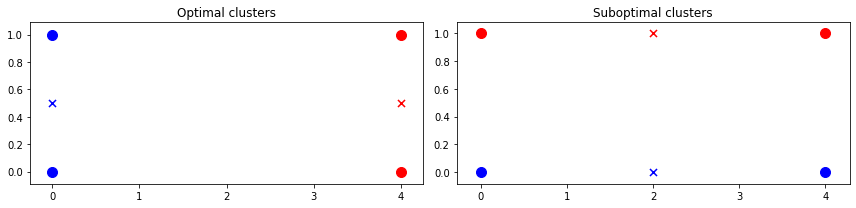

In [366]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 3))
xx = np.array([[0,0], [0,1], [4,0], [4,1]])
axes[0].scatter(xx[:2,0], xx[:2,1], color='blue', s=100)
axes[0].scatter(xx[2:,0], xx[2:,1], color='red', s=100)
axes[0].scatter(0, 0.5, color='blue', marker='x', s=50)
axes[0].scatter(4, 0.5, color='red', marker='x', s=50)
axes[0].set_title('Optimal clusters')
axes[1].scatter(xx[::2,0], xx[::2,1], color='blue', s=100)
axes[1].scatter(xx[1::2,0], xx[1::2,1], color='red', s=100)
axes[1].scatter(2, 0, color='blue', marker='x', s=50)
axes[1].scatter(2, 1, color='red', marker='x', s=50)
axes[1].set_title('Suboptimal clusters')
fig.tight_layout()

In both graphs, the red and blue colors indicate the clusters to which each point is assigned.  The $\times$ symbol indicates the respective cluster means.  Consider that the assignment on the left is optimal if there are just 2 clusters.  The plot on the right, in contrast, is not optimal.  Why? Observe that the points in the clusters on the left are closer to their respective cluster centers than those on the right.  

We can quantify this distinction with the notion of **distortion**.  The *distortion on a point* is its distance to its closest representive&mdash;i.e., the center of its assigned cluster.

Formally, we define the **distortion function** as:

$$J = \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \|{\mathbf{x}_n - \mathbf{\mu}_k}\|^2 $$

where $N$ is the number of training examples, $K$ is the number of clusters, and $r_{nk}\in\{0,1\}$ is a **binary indicator variable**.  Specifically, if a data point $\mathbf{x}_n$ is assigned to cluster $k$, then $r_{nk}=1$ and $r_{nj}=0$ for $j\ne k$. 

The problem is then to find the parameters $\{\mathbf{\mu}_k\}$ and $\{r_{nk}\}$ (centroids and clusters) that minimize $J$.

$$\underset{{\mathbf{R}, \{\mu\}}}{\arg\min} \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \|{\mathbf{x}_n - \mathbf{\mu}_k}\|^2 $$

In [367]:
def distortion(X, clusters, means):
    n, _ = X.shape
    k, _ = means.shape
    
    jScore = 0 # accumulator
    for j in range(k): # iterate over clusters
        jScore += np.sum(
            np.apply_along_axis(
                square_diff, axis=1, 
                arr=(X[clusters == j,:] - means[j])) )
    return jScore

## The $K$-Means Algorithm from Scratch

Let's now implement the algorithm from scratch using only NumPy, without any assistance from scikit-learn or other machine learning toolkits.  In fact, we could implement this without *any* toolkits, including NumPy, but NumPy simplifies our work.  

First, let's walk through the steps of the algorithm.  Then we will assemble these into a function.

### Step 1: Choose $k$ random cluster centers

While in principle we could choose *any* points in $D$-dimensional space, it makes sense to stay within the range of the data that we are working with.  One common approach to choosing the points is to choose $k$ **seed** points from within the dataset itself.  We will use NumPy's `random.choice` to select $k$ indices at random.

In [368]:
# set hyperparameter: number of clusters
k = 3

In [369]:
# initialize centroids with k data points chosen at random
seeds = np.random.choice(shuffle, k) # indices, not actual centroids
centroids = X[seeds, :]
print("seeds selected:")
print(seeds)
print("centroids:")
print(centroids)

seeds selected:
[ 41 120  72]
centroids:
[[1.08217788 0.51854357 0.72145192 0.20290835]
 [1.75853906 0.83417878 1.42035847 0.42836208]
 [1.149814   0.74399729 0.29308984 0.02254537]]


### Step 2: Assign each instance to the closest cluster center

We considered above how to find the distances.  Here we put the vectors of distances into an array, with the rows corresponding to the rows of our dataset and the columns corresponding to the $k$ centroids.  We then use NumPy's `argmin` across the columns to find the index of the closest centroid.  These are our cluster assignments.

In [370]:
# assign points to nearest cluster
assigned_cluster = np.argmin(
    np.array([np.apply_along_axis(
        square_diff, axis=1, arr=(X - centroid)) 
              for centroid in centroids]), 
    axis=0
)

In [371]:
assigned_cluster[:10]

array([2, 2, 0, 1, 0, 2, 0, 0, 0, 2])

### Step 3: Recompute cluster centers

For this step we will iterate over our $k$ clusters.  For the points in each cluster, we then compute the mean of the $D$ coordinates (average column values).  This gives us the new values of our centroids.  **Important:** Note that while our original centroids were seed points from the original dataset, in general the new centroids will not correspond to specific points within the dataset, but they will be point within the range of the data.

In [372]:
centroids = np.array([
    X[assigned_cluster == i, :].mean(axis=0) 
    for i in range(k) 
])
centroids

array([[1.2955815 , 0.59356524, 0.96128804, 0.3004754 ],
       [1.51859188, 0.66830926, 1.25234177, 0.43104605],
       [1.10607598, 0.75031   , 0.30706797, 0.03291624]])

### Step 4: If any cluster center moved, go to Step 2, else return clusters

We will implement this with a `while` loop.  Also, mainly to avoid the possibility of an infinite loop, we will set a limit `max_iter` on the number of times that we will allow the loop to iterate. 

### Putting it all together

We now put these steps together into a function, `kMeans`.

In [373]:
def kMeans(X, k, max_iter=300, verbose=False):
    n = X.shape[0] # number of training instances
    
    # initialize centroids to k "seed points" from within data
    shuffle = np.arange(n)
    seeds = np.random.choice(shuffle, k) # indices, not actual centroids
    centroids = X[seeds, :] # initial centroids are coordinates of the seed points
    
    converged = False
    iter = 0
    old_clusters = [0] * n # converge when clusters do not change
    while not converged and iter < max_iter: 
        
        # assign points to nearest cluster
        clusters = np.argmin(
            np.array([np.apply_along_axis(square_diff, axis=1, arr=(X - center)) 
                      for center in centroids]), axis=0)

        # recompute center clusters
        centroids = np.array([X[clusters == i, :].mean(axis=0) for i in range(k)])
                
        # display current distortion score    
        if verbose: 
            print('J =', distortion(X, clusters, centroids))

        # repeat until we converge
        if np.all(clusters == old_clusters):
            converged = True
        else:
            old_clusters = clusters
            iter += 1
    
    return clusters, centroids

### Testing with a synthetic Gaussian mixture

To test our implementation, we will generate two clusters of synthetic data.  We will generate the data from a mixture of two distinct multivariate Gaussian distributions.  A latent variable will govern the choice of distribution. Three-fifths of the time we will draw from one distribution; the rest of the time, we will draw from the other.  

In [374]:
# First distribution from Wikipedia
μ1 = np.array([0,0]) 
Σ1 = np.array([[1, 3/5], [3/5, 2]])
π1 = 3/5

# The other is one I came up with
# Covariance must be positive semi-definite
# We guarantee that by multiplying by transpose
# μ2 = np.array([4,4])
μ2 = np.array([3,3])
Σ2 = np.array([[1,-1], [-1,-0.5]])
Σ2 = Σ2 @ Σ2.T
print(Σ2)
π2 = 1 - π1

N = 100
X = np.empty(shape=(0,2))
y = np.empty(shape=(0,1))
for _ in range(N):
    if np.random.random() < π1:
        t = 1 # class 1
        x = gaussian(μ1, Σ1, (1,))
    else:
        t = 0 # the other class
        x = gaussian(μ2, Σ2, (1,))
    X = np.append(X, x, axis=0)
    y = np.append(y, t)

[[ 2.   -0.5 ]
 [-0.5   1.25]]


In [375]:
clusters, means = kMeans(X, 2, verbose=True)

J = 288.36199381059987
J = 259.2410570446139
J = 254.95376533100233
J = 254.95376533100233


In [376]:
means

array([[ 0.08694239, -0.37041528],
       [ 2.81577459,  2.97894787]])

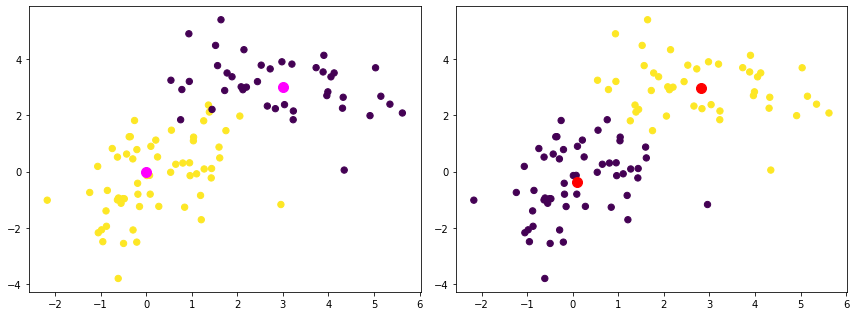

In [377]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))
# Plot Gaussian mixture
axes[0].scatter(X[:,0], X[:,1], c=y, s=40)
axes[0].scatter(μ1[0], μ1[1], color='magenta', s=100)
axes[0].scatter(μ2[0], μ2[1], color='magenta', s=100)
# Plot learned clusters
axes[1].scatter(X[:,0], X[:,1], c=clusters, s=40)
for i in range(2):
    axes[1].scatter(means[i,0], means[i,1], color='red', s=100)
fig.tight_layout()

In [378]:
score = max(sum(clusters == y), sum(clusters != y)) / N
score

0.94

In [379]:
np.append(μ1, μ2).reshape(2,2)

array([[0, 0],
       [3, 3]])

In [380]:
means

array([[ 0.08694239, -0.37041528],
       [ 2.81577459,  2.97894787]])

In [381]:
print(Σ1)
print(Σ2)

[[1.  0.6]
 [0.6 2. ]]
[[ 2.   -0.5 ]
 [-0.5   1.25]]


In [382]:
np.corrcoef(X[clusters == 0, :].T)

array([[1.        , 0.31155056],
       [0.31155056, 1.        ]])

In [383]:
np.corrcoef(X[clusters == 1, :].T)

array([[ 1.        , -0.22938308],
       [-0.22938308,  1.        ]])

## $K$ Means with Random Restarts

Note that the cost function is guaranteed to decrease non-monotonically to a local minimum.  In general, however, the algorithm will not converge to the global minimum.  It is particularly sensitive to the choice of seed points.  (Note that some algorithms choose the seed points in a clever way to facilitate faster convergence, but this still does not guarantee convergence to a global minimum.) 

We can attempt to improve by running the algorithm many times and choosing a result with lowest distortion cost $J$.

Note (S21): There is a non-critical bug in here somewhere.  I think the issue is that a cluster could be empty, causing NumPy to throw an exception.  

In [384]:
def bestKMeans(X, k, nTrials=100):
    bestJ = float('inf')
    bestClusters = None
    bestMeans = None
    for trial in range(nTrials):
        clusters, means = kMeans(X, k)
        try:
            J = distortion(X, clusters, means)
        except:
            pass # avoid bug when everything in one cluster?
        if J < bestJ:
            print('trial', trial, ': J =', J)
            bestJ = J
            bestClusters = clusters
            bestMeans = means
    return bestClusters, bestMeans

In [385]:
clusters, means = bestKMeans(X, 2, 100)

trial 0 : J = 254.8792005722732


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: RuntimeWarning: Mean of empty slice.
/opt/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:154: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [386]:
clusters[:20]

array([0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1])

In [387]:
means

array([[ 0.07453094, -0.41150131],
       [ 2.77102212,  2.95436705]])

## Testing with the IRIS data

Let's now apply the method to the IRIS data.  Keep in mind that the IRIS dataset is usually approached as a **supervised** machine learning problem.  But if we ask $k$-means to find 3 clusters, is it possible that those will correspond to the three varieties of Iris?  Let's find out! 

### Load and prep the data

In [388]:
# load data
data = datasets.load_iris()
X = data.data[:, :]  
y = data.target # note: we won't really use this until the end
N, D = X.shape # number rows and columns

In [389]:
# scale and randomly shuffle data
X = (X - X.min()) / (X.max() - X.mean())

In [390]:
# shuffle the data 
shuffle = np.arange(N)
np.random.shuffle(shuffle)
X = X[shuffle,:]
y = y[shuffle]

In [391]:
X[:5,:] # first 5 rows of scaled, randomly shuffled features

array([[1.53308533, 0.67636118, 1.12726863, 0.4959982 ],
       [1.10472326, 0.69890655, 0.2479991 , 0.02254537],
       [1.33017698, 0.47345282, 0.87926953, 0.20290835],
       [1.03708714, 0.69890655, 0.33818059, 0.02254537],
       [0.99199639, 0.4959982 , 0.27054447, 0.04509075]])

In [392]:
y[:5] # class labels corresponding to the 3 varieties of Iris flowers.

array([2, 0, 1, 0, 0])

### Apply kMeans

In [393]:
# set hyperparameter: number of clusters
k = 3

In [406]:
clusters, means = bestKMeans(X, k)
# clusters, means = kMeans(X, k, verbose=True)

trial 0 : J = 4.007970068820619


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: RuntimeWarning: Mean of empty slice.
/opt/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:154: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [407]:
clusters[:20]

array([2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 0, 0, 0])

In [408]:
y[:20]

array([2, 0, 1, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 0, 1, 2, 0, 0, 0])

### Attempt to map clusters to labels

Of course, kMeans knows nothing of our labels.  It's an unsupervised method, so we don't pass the vector $\mathbf{y}$ of class labels to it.  In any event, the labels are completely arbitrary from a mathematical standpoint.  But id does look like maybe we can map the labels in the clusters to those in our $\mathbf{y}$ vector.  Let's attempt this with NumPy's `stats.mode` method.

In [397]:
def mapClustersToClassLabels(clusters, labels):
    # try to automate the mapping between the class labels
    # note that this doesn't always succeed! 
    # we'd need a cleverer method
    map = {i : stats.mode(y[clusters == i]).mode[0]  for i in range(k)}
    return np.array([map[i] for i in clusters]) # permute

In [409]:
clusters = mapClustersToClassLabels(clusters, y)

In [410]:
clusters[:20]

array([2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 0, 0, 0])

How closely do the labels align? 

In [411]:
np.sum(clusters == y) / len(y)

0.8933333333333333

### Different values of $k$

Suppose we asked $k$-means to find only two clusters?  Would those align with out dataset in any meaningful way?  Again, let's find out!

In [412]:
clusters, means = kMeans(X, 2)
print(clusters[:35])
print(y[:35])

[0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 1 1 1]
[2 0 1 0 0 2 2 2 1 2 2 2 1 2 0 1 2 0 0 0 2 1 0 1 0 0 0 1 2 0 2 2 0 0 0]


The mapping again appears meaningful.  It seems that the algorithm has placed the *Setosa* variety in one cluster and the other two varieties in the other cluster.  Recall from earlier supervised experiments that the *Setosa* variety was linearly separable from the other two varieties, which were more similar to one another.  

Unfortunately, now that the number of clusters doesn't match up with the number of labels, we can't apply our mapping function to the result.  But from inspecting the data manually, we can understand what it does.  

What if we had it find 4 clusters, or 5?

In [413]:
clusters, means = kMeans(X, 5)
print(clusters[:35])
print(y[:35])

[2 1 4 1 1 0 0 2 4 2 0 2 2 0 1 2 0 1 3 3 2 4 3 4 3 3 1 2 0 1 2 2 1 3 3]
[2 0 1 0 0 2 2 2 1 2 2 2 1 2 0 1 2 0 0 0 2 1 0 1 0 0 0 1 2 0 2 2 0 0 0]


## Sklearn's KMeans implementation

While $k$-means is one of the simpler machine learning methods, you can nevertheless use scikit-learn's implementation in DSC 305.  First, import the package:

```
from sklearn import cluster
```

Then run it with `cluster.Means(n_clusters=k)` where `k` is the number of clusters.

In [414]:
k_means = cluster.KMeans(n_clusters=3)
k_means.fit(X)
clusters2 = mapClustersToClassLabels(k_means.labels_, y)
np.sum(clusters2 == y) / len(y)

0.8933333333333333

In [415]:
k_means

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [416]:
k_means.labels_

array([2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 2, 0, 1, 2, 0,
       2, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 1, 0, 1, 0, 2, 2, 1, 0,
       0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 1, 0, 1, 0, 2, 1, 2, 1, 1, 2, 0, 0,
       2, 0, 0, 1, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1,
       2, 0, 2, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1,
       1, 0, 2, 1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1], dtype=int32)

### Future work

To do:

* Discuss alternate approaches to initialization:
  * Specifically, Arthur and Vassilvitskii, kMeans++ (note: default in sklearn, above)
* Provide code for the online version and give hints on how to derive the derivative. 
* Discuss the applicability of Voronoi regions (plotting them if possible)
